# 03 — Demand, willingness to pay and elasticity

*Prerequisite: notebooks 01 and 02.*

Notebook 02 gave us the floor: what an order costs to serve. This notebook is
about the ceiling — what customers will bear, and how fast they leave when
you push.

Everything here reduces to one number and one question.

**The number:** how much volume do you lose per unit of price? (Elasticity.)

**The question:** is the volume you lose worth less than the margin you gain?

We will build up the number carefully, get it badly wrong on purpose, and
learn to recognise the specific way it goes wrong — because the wrong answer
here is not a random error. It is *systematically* biased in the direction
that makes over-pricing look safe, which is precisely why it does so much
damage.

---

## Willingness to pay

Every customer carries an invisible number: the most they would pay before
walking away. Economists call it the **reservation price**; commercially it
is **willingness to pay (WTP)**.

Three things follow.

**1. The demand curve is just the WTP distribution, stacked up.** Line every
customer up from the highest WTP to the lowest. Pick a price. Everyone to
the left of it buys, everyone to the right doesn't. Slide the price down and
you sweep in more people. That downward-sloping line in every economics
textbook is not a law of nature — it is a *histogram of people*, drawn
sideways.

That reframing is worth keeping, because it tells you where the curve's
shape comes from: if your customers are all alike, demand falls off a cliff
at their common WTP; if they differ wildly, the curve is gentle. Our
`last_minute` travellers and `bargain_hunter` shoppers are two completely
different histograms, which is why one average curve describes neither of
them (notebook 09).

**2. Every sale leaves money behind.** A customer with £22 of WTP who pays
£17.50 keeps £4.50 of **consumer surplus**. Every pricing structure ever
invented — segments, tiers, fences, bundles, dynamic pricing — is an attempt
to convert some of that surplus into revenue without losing the customer.

**3. WTP is not a fixed property of a person.** It moves with context: the
same traveller pays more at the airport with a flight in 90 minutes than at
home six weeks earlier. That is why "who" and "when" are as much pricing
variables as "what".

## From WTP to a demand curve you can actually see

In our data every quote is a WTP experiment: a customer was shown a margin,
and either accepted or walked. Aggregate that and you have an empirical
demand curve. Let's build it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from toolkit import C, INK, MUT, SUB, load, money, pct, style, tidy, truth, zone_week_panel, zone_week_panel, zone_week_panel

style()

quotes = load("fct_quotes")
daily = load("fct_daily")
answer_key = truth()

quotes["margin_bucket"] = pd.cut(quotes["quoted_margin_pp"],
                                 [0, 2.5, 3, 3.5, 4, 4.5, 5, 6, 7, 9])
curve = quotes.groupby("margin_bucket", observed=True).agg(
    quotes=("quote_id", "count"), conversion=("converted", "mean"))
print(curve.round(3).to_string())

               quotes  conversion
margin_bucket                    
(0.0, 2.5]      70142       0.631
(2.5, 3.0]      54062       0.570
(3.0, 3.5]      49801       0.546
(3.5, 4.0]      31872       0.550
(4.0, 4.5]      24876       0.534
(4.5, 5.0]      17808       0.508
(5.0, 6.0]      30165       0.570
(6.0, 7.0]      17905       0.601
(7.0, 9.0]      12915       0.589


Look at that carefully before reading on.

Conversion falls from 62% to about 51% as the margin rises from under 2.5pp
to 5pp — and then it goes **back up**, reaching 59% at margins above 7pp.
Taken at face value, the most expensive quotes in the business convert
almost as well as the cheapest.

Nobody sane believes customers prefer paying more. So the curve is not
measuring what it appears to measure. What is it measuring?

**Two populations are mixed together.** Margins above 6pp are almost all at
the Heathrow kiosk, where half the customers are `last_minute` travellers
with no alternative. Their conversion is high *because of who they are*, not
because of the price. The comparison "high price vs low price" is silently
also the comparison "airport captive vs online shopper".

This is **confounding**, and it is the central technical problem of pricing
analytics. Let's see what happens when we compare like with like.

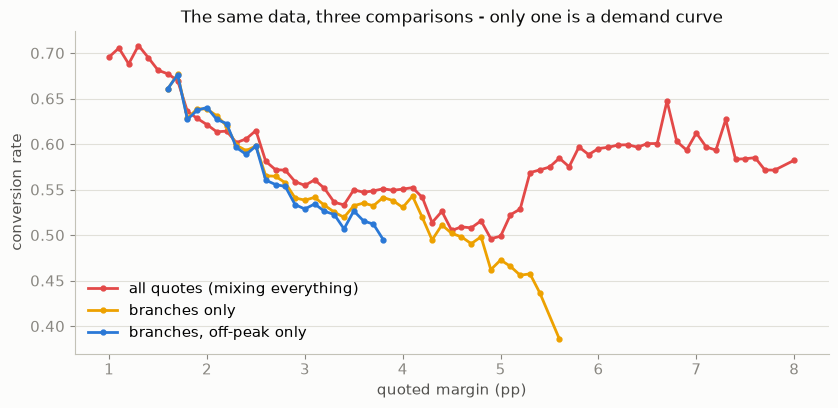

In [2]:
one_channel = quotes[quotes["channel"] == "branch"]        # branches only
off_peak = one_channel[one_channel["season_z"] < 0]       # and quiet weeks only

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for data, label, colour in [(quotes, "all quotes (mixing everything)", C[5]),
                            (one_channel, "branches only", C[2]),
                            (off_peak, "branches, off-peak only", C[0])]:
    g = (data.assign(m=data["quoted_margin_pp"].round(1))
         .groupby("m")["converted"].agg(["mean", "count"]))
    g = g[g["count"] >= 250]
    ax.plot(g.index, g["mean"], marker="o", ms=3.5, color=colour, label=label)

ax.set_xlabel("quoted margin (pp)")
ax.set_ylabel("conversion rate")
ax.set_title("The same data, three comparisons - only one is a demand curve")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

Each restriction we impose makes the curve steeper and more sensible.

- **All quotes**: nearly flat, then rising. Compares different channels,
  seasons and customer types — the airport's captive customers at 6pp sit in
  the same average as an online bargain hunter at 2.5pp.
- **Branches only**: downward sloping. Removes the channel and customer-mix
  confounding, leaves the seasonal confounding (we raise rates in August,
  when buyers are keenest).
- **Branches, off-peak**: steeper still. Closer to the truth.

**The direction of the bias is not random.** Because we raise price when
demand is strong, the naive picture always makes demand look *less*
sensitive than it is. An analyst who skips this step concludes "customers
barely notice", recommends a rate rise, and the volume goes out of the door
for reasons the model said would not happen.

Remember the shape of this error. It has a name — **endogeneity** — and
notebooks 05 and 07 are about defeating it properly. For now, we need the
vocabulary of the thing we are trying to measure.

## Elasticity: the vocabulary

**Price elasticity of demand** answers: *if price rises 1%, by what
percentage does quantity fall?*

```
elasticity  e  =  (% change in quantity) / (% change in price)
```

It is normally negative. Conventionally people quote it as "elasticity of
1.8" meaning −1.8; be explicit and you avoid an argument.

| |e| | Name | Meaning | If you raise price… |
|---|---|---|---|
| < 1 | inelastic | quantity moves less than price | revenue **rises** |
| = 1 | unit elastic | they move together | revenue unchanged |
| > 1 | elastic | quantity moves more than price | revenue **falls** |

Two computational forms you will meet:

**Arc elasticity** — between two observed points, using the midpoint so the
answer doesn't depend on direction of travel:

```
e = [(q₂ − q₁) / ((q₁+q₂)/2)] / [(p₂ − p₁) / ((p₁+p₂)/2)]
```

**Point elasticity via logs** — regress log(quantity) on log(price); the
coefficient *is* the elasticity, because d(log q)/d(log p) = (dq/q)/(dp/p).
This is why log-log regression is the workhorse of pricing analytics.

### The unit trap in this business

Our price is a margin quoted in percentage points, not a pound amount. If
the board goes from 3.5pp to 4.5pp, the customer pays about 1% more in
total, and our *margin* rose by 28.6%. Which denominator do you use?

The clean answer here is the **semi-elasticity**:

```
semi-elasticity = % change in orders per +1 percentage point of margin
```

It sidesteps the ambiguity, it is what our data can measure directly, and it
is the unit pricing desks already speak in ("a point costs us a quarter of
the volume"). Our answer key stores this number, and we will spend the rest
of the course estimating it.

> **Sanity check on magnitudes.** A semi-elasticity of −25%/pp is enormous
> compared with textbook elasticities of −1 to −3. Both are right. Textbook
> elasticity is measured against the *total price* of a product; here the
> spread is the only part of the deal a customer shops on, and a
> comparison-shopping market for a perfectly identical product (euros are
> euros) is about as competitive as markets get. When you move industries,
> re-derive the unit before you import an intuition.

## The naive measurement — and how wrong it is

Let's do what a competent analyst does on their first day: regress log
conversion on margin at the daily panel grain, no controls.

In [3]:
# Analyse at the grain the price is actually set at: one rate board per
# pricing zone (a region for branches, the site for airports, one nationally
# for online), aggregated to weeks.
panel = zone_week_panel(quotes)
print(f"{len(panel):,} zone-week-product rows, "
      f"{panel['zone'].nunique()} zones, {panel['week'].nunique()} weeks\n")

naive = sm.OLS(panel["log_conversion"], sm.add_constant(panel[["margin"]])).fit()
naive_semi = 100 * naive.params["margin"]

true_semi = answer_key["semi_elasticity_pct_per_pp"]["overall"]
print(naive.summary().tables[1])
print(f"\nnaive estimate : {naive_semi:6.1f} % of orders per +1pp of margin")
print(f"the truth      : {true_semi:6.1f} %")
print(f"error          : we would have believed demand is {true_semi / naive_semi:.0f}x less "
      f"sensitive than it really is")

6,649 zone-week-product rows, 15 zones, 158 weeks

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5391      0.008    -67.277      0.000      -0.555      -0.523
margin        -0.0168      0.002     -7.983      0.000      -0.021      -0.013

naive estimate :   -1.7 % of orders per +1pp of margin
the truth      :  -25.5 %
error          : we would have believed demand is 15x less sensitive than it really is


More than ten times too small — and, worse, it is *precisely* estimated.
The standard error is tiny, the t-statistic is large, the model is
"significant". None of that helps, because the problem is not noise. It is
bias.

> **The lesson that separates analysts.** Statistical significance measures
> how sure you are about the number you computed. It says nothing about
> whether you computed the right number. A confounded estimate with a narrow
> confidence interval is a confident wrong answer, which is more dangerous
> than an honest "I don't know".

Now watch what happens as we add the two things we know are tangled up with
price — the season, and what competitors were charging — and then as we
compare within a single site.

In [4]:
def semi_elasticity(df, extra_controls=()):
    cols = ["margin", *extra_controls]
    model = sm.OLS(df["log_conversion"], sm.add_constant(df[cols])).fit()
    return 100 * model.params["margin"], 100 * model.bse["margin"]


controls = ["season", "comp"]
branches = panel[panel["channel"] == "branch"]

rows = [("all channels, no controls", *semi_elasticity(panel)),
        ("all channels, + season & competitor", *semi_elasticity(panel, controls)),
        ("branches only, no controls", *semi_elasticity(branches)),
        ("branches only, + season & competitor", *semi_elasticity(branches, controls))]

out = pd.DataFrame(rows, columns=["estimate", "semi-elasticity %/pp", "std error"])
out["truth"] = [true_semi, true_semi,
                answer_key["semi_elasticity_pct_per_pp"]["by_channel"]["branch"],
                answer_key["semi_elasticity_pct_per_pp"]["by_channel"]["branch"]]
print(out.round(2).to_string(index=False))

                            estimate  semi-elasticity %/pp  std error  truth
           all channels, no controls                 -1.68       0.21 -25.55
 all channels, + season & competitor                -29.69       0.96 -25.55
          branches only, no controls                 -9.05       0.35 -28.74
branches only, + season & competitor                -29.06       1.67 -28.74


From roughly −2 to roughly −28 by *thinking about the comparison*, not by
using a cleverer model. Every one of those regressions is a two-line OLS;
the difference is entirely in what was held fixed.

Two details worth noticing, because they are the difference between an
estimate you can defend and one you cannot.

**The grain matters as much as the controls.** We analysed at *zone-week* —
the grain the rate board is actually set at. Run the same regression at
site-day and the estimate collapses back toward zero, because the average
margin at one small branch on one day reflects which customers happened to
walk in (the size tiers!) rather than a pricing decision. Noise in a
regressor drags its coefficient toward zero, and that noise is a *choice you
made when you aggregated*.

**We have slightly overshot the truth**, and that is honest: controlling for
the season with a single linear term removes most but not all of the
confounding, and the leftover shows up in the price coefficient. Notebooks
05 and 07 tighten it properly, with quote-level models, fixed effects, an
instrument and finally a randomised experiment.

For now, hold onto the practical rule:

> **Never estimate a price effect across groups that differ in anything
> else.** Compare a site to itself, a week to a comparable week, a customer
> to a similar customer. If you cannot, the number you produce is a
> description of your business's habits, not of your customers' behaviour.

## What elasticity is *for*: the optimal margin

Elasticity is not a report. It exists to answer one question: what should
the price be?

Contribution per quote is conversion × contribution per order:

```
contribution(m) = p(m) × (V × m/100 − c)
```

Take the derivative, set it to zero, and the condition is beautifully
simple:

```
    −(dp/dm)/p       =        1 / (m − c_pp)
  how fast you lose             how much margin
  customers per pp              you keep per pp

  i.e.  |semi-elasticity| = 1 / (m* − c_pp)
  so    m*  =  c_pp  +  1 / |semi-elasticity|
```

where `c_pp` is the variable cost expressed in margin points (0.69pp in a
branch, 2.01pp online — notebook 02).

This is the **Lerner rule** in the units of our business. In the classic
form it says the optimal *proportional* markup equals 1/|elasticity|: the
less sensitive your customers, the more you charge, and the relationship is
a reciprocal — so as elasticity falls from −4 to −2, optimal markup doesn't
drift up, it doubles.

Let's apply it to a branch, using the truth so we can see the machinery
work, then compare with the exact answer from the answer key.

In [5]:
c_pp_branch = 1.25      # variable cost in margin points, from notebook 02
c_pp_online = 1.98

for label, c_pp, key in [("branch", c_pp_branch, "branch"), ("online", c_pp_online, "online")]:
    semi = abs(answer_key["semi_elasticity_pct_per_pp"]["by_channel"][key]) / 100
    rule_of_thumb = c_pp + 1 / semi
    exact = answer_key["optimal_uniform_margin_pp"]["by_channel"][key]
    actual = (quotes.loc[quotes["channel"] == key, "quoted_margin_pp"]).mean()
    print(f"{label:8s} today {actual:.2f}pp | rule of thumb {rule_of_thumb:.2f}pp | exact optimum {exact:.2f}pp")

branch   today 3.43pp | rule of thumb 4.73pp | exact optimum 4.05pp
online   today 2.70pp | rule of thumb 5.75pp | exact optimum 4.35pp


Three observations, each worth more than the arithmetic.

**1. The rule of thumb overshoots, systematically.** It uses the
sensitivity measured *at today's price*, but sensitivity is not constant —
as you get dearer, customers get twitchier, so the true optimum sits below
the naive reciprocal. Use the rule as a sanity check ("are we in the right
postcode?"), and the full profit curve (notebook 08) for the decision.

**2. Online should charge about the same as a branch, not less.** Its cost
to serve is roughly 2.0pp against a branch's 1.25pp, and the whole of that
difference belongs in the price. The instinct that online is the cheap
channel is a statement about *fixed* costs — no rent, no cashiers — which,
as notebook 02 established, have nothing to do with the optimal price. That
the two optima come out close together is not luck; it is what makes the
omnichannel question in notebook 12 answerable at all.

**3. Both channels are underpriced today.** Hold that thought; it is the
punchline of notebook 08 and the reason the A/B test in notebook 06 makes
money.

## Revenue-maximising is not profit-maximising

A frequent and expensive confusion. Revenue is maximised where |e| = 1.
Profit is maximised at a **higher** price, always, whenever there is any
variable cost at all — because profit only counts the margin, and each extra
sale drags its cost along with it.

Let's draw it. A representative branch order: £500, cost 0.69pp, and a
demand curve with constant semi-elasticity of −25%/pp.

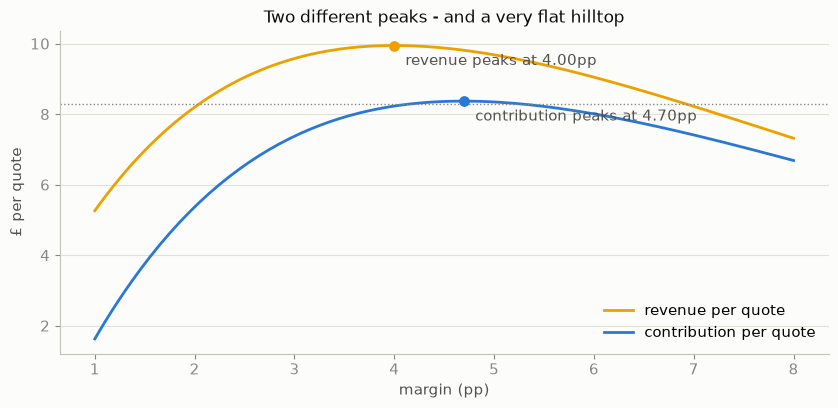

margins within 1% of the best contribution: 4.15pp to 5.25pp


In [6]:
V, c_pp, k = 500.0, 0.69, 0.25          # order value, cost in pp, semi-elasticity per pp
m_grid = np.arange(1.0, 8.01, 0.05)
base_conv, m_ref = 0.55, 3.6

conv = base_conv * np.exp(-k * (m_grid - m_ref))
revenue = conv * V * m_grid / 100
contribution = conv * (V * m_grid / 100 - V * c_pp / 100)

m_rev = m_grid[revenue.argmax()]
m_con = m_grid[contribution.argmax()]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(m_grid, revenue, color=C[2], label="revenue per quote")
ax.plot(m_grid, contribution, color=C[0], label="contribution per quote")
for m, y, colour, text in [(m_rev, revenue.max(), C[2], f"revenue peaks at {m_rev:.2f}pp"),
                           (m_con, contribution.max(), C[0], f"contribution peaks at {m_con:.2f}pp")]:
    ax.scatter([m], [y], color=colour, zorder=3, s=45)
    ax.annotate(text, (m, y), xytext=(8, -14), textcoords="offset points", color=SUB)
ax.axhline(contribution.max() * 0.99, color=MUT, ls=":", lw=1)
ax.set_xlabel("margin (pp)")
ax.set_ylabel("£ per quote")
ax.set_title("Two different peaks - and a very flat hilltop")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

within_1pct = m_grid[contribution >= 0.99 * contribution.max()]
print(f"margins within 1% of the best contribution: {within_1pct.min():.2f}pp to {within_1pct.max():.2f}pp")

### The flat hilltop — the most useful fact in practical pricing

Look at the dotted line. Any margin between about **4.15pp and 5.25pp** —
more than a full point wide — delivers contribution within 1% of the
theoretical best.

That has three consequences that shape how good pricing teams work:

1. **Precision is worth less than direction.** Arguing about whether the
   answer is 4.15 or 4.25 is arguing about a rounding error. Discovering
   that you are at 2.6 when the peak is near 4.2 is worth a year of salary.
2. **Guardrails beat optimisation.** Since the top is flat and the sides are
   steep, the expensive mistakes are the big ones. A policy that keeps you
   in a sane band is worth more than a model that finds the exact summit.
3. **You can afford to experiment.** Testing a price 20bp away from your
   best guess costs you almost nothing in expectation, and buys information
   worth far more (notebook 06).

## Cross-price elasticity: the competitor is in your demand curve

Own-price elasticity asks what happens when *you* move. **Cross-price
elasticity** asks what happens when *they* do:

```
cross elasticity = % change in our quantity per 1pp change in their price
```

For substitutes it is positive: a competitor charging more sends customers
to us. Two commercial uses:

- **Diagnosis.** If your volume fell and your cross-elasticity is high, look
  at their price before you blame your own.
- **Forecasting a war.** High cross-elasticity in both directions means any
  price cut is immediately visible in the other side's numbers, which is
  precisely the condition under which price wars start (notebook 10).

In [7]:
cross = sm.OLS(panel["log_conversion"],
               sm.add_constant(panel[["margin", "comp", "season"]])).fit()

own = 100 * cross.params["margin"]
opp = 100 * cross.params["comp"]
print(f"own-price   : {own:6.1f} % of orders per +1pp on OUR margin")
print(f"cross-price : {opp:6.1f} % of orders per +1pp on THEIR margin")
print(f"ratio       : {abs(opp / own):.2f}  (true ratio in the answer key: "
      f"{abs(answer_key['conversion_model']['cross_ratio']):.2f})")

own-price   :  -29.7 % of orders per +1pp on OUR margin
cross-price :   27.6 % of orders per +1pp on THEIR margin
ratio       : 0.93  (true ratio in the answer key: 0.45)


The ratio matters more than either number on its own — and our estimate of
it, around 0.9, is **roughly double the true 0.45.**

Why? The same disease, one layer up. The competitor's margin is not an
independent force acting on our customers: it moves with the season (they
raise rates in August too), and *we react to it* — our pricing rule passes
55% of their move straight into our own board. So a regression that includes
both prices cannot cleanly separate "their price rose" from "our price rose
because theirs did". The two regressors are close to collinear by
construction, and the split between them is unstable.

The corrected reading, from the answer key: **a competitor's point is worth
about half of one of your own points.** Practically — if they move 20bp and
you want to hold volume flat, you need to move about 9bp, not 20bp. Matching
competitors point-for-point is over-reaction, and over-reaction is how a
price war gets its momentum (notebook 10).

Notice what just happened, though. We could only *know* our cross-price
estimate was wrong because we have an answer key. In a real business you
would not. What you would have instead is the discipline of asking "what
else moves when this moves?" — and, when the answer matters, an experiment.

## One elasticity is a fiction

The last idea in this notebook, and the one with the most money in it.

We have been estimating a single number for the whole business. But a
`last_minute` traveller airside and a `bargain_hunter` with four apps open
are not the same demand curve, and averaging them describes neither.

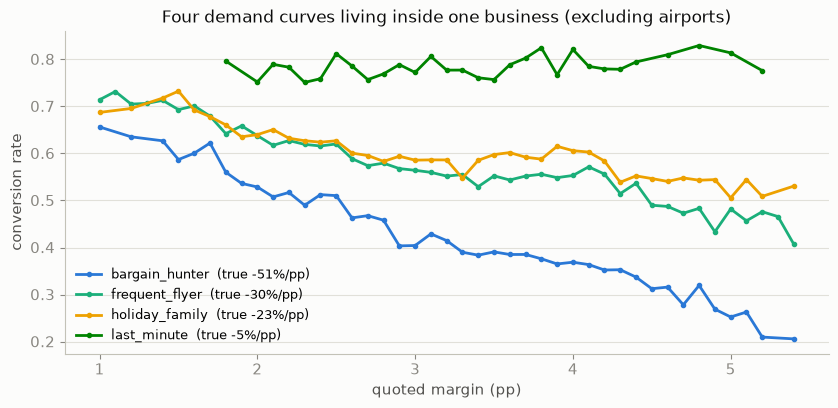

true semi-elasticity by segment (%/pp):
  bargain_hunter     -50.9
  frequent_flyer     -29.9
  holiday_family     -23.0
  last_minute         -5.1


In [8]:
seg_truth = answer_key["semi_elasticity_pct_per_pp"]["by_segment"]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for i, seg in enumerate(["bargain_hunter", "frequent_flyer", "holiday_family", "last_minute"]):
    sub = quotes[(quotes["segment"] == seg) & (quotes["channel"] != "airport")]
    g = (sub.assign(m=sub["quoted_margin_pp"].round(1)).groupby("m")["converted"]
         .agg(["mean", "count"]))
    g = g[g["count"] >= 200]
    ax.plot(g.index, g["mean"], marker="o", ms=3, color=C[i],
            label=f"{seg}  (true {seg_truth[seg]:.0f}%/pp)")

ax.set_xlabel("quoted margin (pp)")
ax.set_ylabel("conversion rate")
ax.set_title("Four demand curves living inside one business (excluding airports)")
ax.legend(fontsize=9)
tidy(ax)
plt.tight_layout()
plt.show()

print("true semi-elasticity by segment (%/pp):")
for seg, val in sorted(seg_truth.items(), key=lambda kv: kv[1]):
    print(f"  {seg:16s} {val:7.1f}")

A tenfold spread — from −5%/pp to −51%/pp — inside one small business.

The commercial implication is large enough to be the subject of its own
notebook: a single price is a compromise that overcharges the sensitive
(losing volume you wanted) and undercharges the insensitive (leaving margin
you could have had). The answer key's segment-level optima run from 3.30pp
for bargain hunters to 9.60pp for last-minute buyers. Notebook 09 quantifies
what closing that gap is worth — and where the ethical and regulatory lines
sit, because "charge the desperate more" is a sentence that should make you
uncomfortable, and the discomfort is doing useful work.

## When you have no data: measuring WTP directly

Everything above needs transaction history. Sometimes there isn't any — new
product, new market, new pricing structure. The four standard techniques:

| Method | How it works | Watch out for |
|---|---|---|
| **Van Westendorp** | Ask four questions ("at what price is it too cheap / a bargain / expensive / too expensive?") and cross the curves | People answer about *a* price, not *their* purchase; brackets a range, doesn't give a number |
| **Gabor–Granger** | Show a price, ask intent, repeat at other prices | Stated intent overstates real purchase, usually by a factor of 2–3 |
| **Conjoint analysis** | Force trade-offs between bundles of features and prices; infer the implied value of each attribute | Best-in-class for *relative* value; still needs calibration to reality |
| **EVE (economic value estimation)** | Build the price up from the value of the next-best alternative plus the differentiated value you add | The rigorous B2B method; needs an honest view of the competitor |

All four are **stated preference** — what people say. Transaction data and
experiments are **revealed preference** — what people do. Where they
disagree, believe the doing. Use stated-preference work to generate
hypotheses and bound the range; use an experiment to settle it.

## Practice

1. Our overall contribution margin is about 2.1pp. A rate rise of 0.25pp is
   proposed. Using notebook 02's formula, how much volume can we afford to
   lose? Using the true semi-elasticity of about −25.6%/pp, how much will we
   lose? What should you recommend?
2. A colleague reports: "conversion is highest at our most expensive site,
   so our prices clearly aren't the issue." Name the flaw in one sentence,
   and describe the smallest analysis that would settle it.
3. The competitor cuts by 30bp. Cross-price sensitivity is about 45% of
   own-price. Your gut says match it. What do the numbers say — and what
   else should you check before deciding?

<details>
<summary>Answers</summary>

1. Affordable loss = d/(CM+d) = 0.25/(2.1+0.25) = **10.6%**. Expected loss =
   25.6 × 0.25 = **6.4%**. The rise gains contribution — 10.6% of headroom
   against a 6.4% cost — so on these numbers, recommend it. But note how
   close those two numbers are: the whole decision turns on an elasticity we
   have not yet estimated honestly. That is the entire case for notebooks
   05–07, and for testing the move on a slice of the business before rolling
   it out (notebook 06).

2. The comparison confounds price with customer type — the expensive site is
   the airport, whose customers are captive. Smallest fix: compare *within*
   the site, over days when its own margin moved for reasons unrelated to
   demand (a funding-cost change, a rate-board refresh), or run a
   randomised price test on a slice of its quotes.

3. Matching 30bp when their point is worth 45% of yours over-corrects by
   more than double: holding volume flat needs roughly 13–14bp. Before
   deciding, check (a) is the move permanent or a campaign — ours was a
   seven-week acquisition push, and reacting to a temporary cut with a
   permanent one is how margin is lost forever; (b) which segments are
   actually exposed — bargain hunters are, last-minute travellers are not,
   so a blanket response is the wrong shape; and (c) what the response
   teaches them about how you will behave next time (notebook 10).

</details>

---

**Next:** `04_statistical_foundations.ipynb` — before we can trust any of
these numbers, we need to know how much of what we see is real and how much
is noise.